In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import os

# RELOAD CLEANED DATA  (run after tasks1_3_fixed.py logic)

DATA_PATH = r"D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 2\beijing+multi+site+air+quality+data\PRSA2017_Data_20130301-20170228"

all_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

# Cleaning (same as Task 2)
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.sort_values(["station", "datetime"]).reset_index(drop=True)
numeric_cols = df.select_dtypes(include="number").columns.tolist()
df[numeric_cols] = df.groupby("station")[numeric_cols].transform(
    lambda x: x.ffill().bfill()
)
pollutants = [c for c in ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"] if c in df.columns]
df.dropna(subset=pollutants, inplace=True)
df.drop_duplicates(inplace=True)

os.makedirs("outputs", exist_ok=True)

In [9]:

# TASK 4: Data Filtering

print("TASK 4: Data Filtering")

# Step 1: Average pollution per station
print("\n Average Pollution Levels by Station ")
avg_by_station = df.groupby("station")[pollutants].mean().round(2)
print(avg_by_station.to_string())

# Step 2: Highest and lowest PM2.5 station
if "PM2.5" in df.columns:
    pm25_avg = df.groupby("station")["PM2.5"].mean().round(2)
    highest_station = pm25_avg.idxmax()
    lowest_station  = pm25_avg.idxmin()
    print(f"\n Highest average PM2.5: {highest_station} ({pm25_avg[highest_station]} µg/m³)")
    print(f" Lowest  average PM2.5: {lowest_station}  ({pm25_avg[lowest_station]} µg/m³)")

# Step 3: Hazardous hours (PM2.5 > 150)
if "PM2.5" in df.columns:
    print("\n Hazardous Hours (PM2.5 > 150 µg/m³) per Station ")
    hazard = df[df["PM2.5"] > 150].groupby("station")["PM2.5"].count().sort_values(ascending=False)
    print(hazard.to_string())




TASK 4: Data Filtering

 Average Pollution Levels by Station 
               PM2.5    PM10    SO2    NO2       CO     O3
station                                                   
Aotizhongxin   83.16  110.73  17.57  59.29  1267.07  55.18
Changping      71.12   94.79  14.96  44.24  1160.04  58.04
Dingling       67.43   84.22  11.77  27.32   924.76  71.98
Dongsi         86.31  110.58  18.53  52.19  1363.24  57.53
Guanyuan       83.05  109.22  17.61  57.96  1246.66  54.86
Gucheng        84.35  119.33  16.02  55.79  1352.70  58.70
Huairou        69.95   92.65  12.26  32.04  1022.40  61.35
Nongzhanguan   85.29  109.47  18.76  58.14  1325.17  58.45
Shunyi         80.02   99.70  13.45  44.56  1203.95  53.86
Tiantan        82.26  106.66  14.48  53.24  1308.28  56.46
Wanliu         83.52  110.66  18.42  65.97  1331.70  46.92
Wanshouxigong  85.36  112.73  17.37  55.64  1376.91  55.98

 Highest average PM2.5: Dongsi (86.31 µg/m³)
 Lowest  average PM2.5: Dingling  (67.43 µg/m³)

 Hazardous Hours 

TASK 5: Data Visualisation


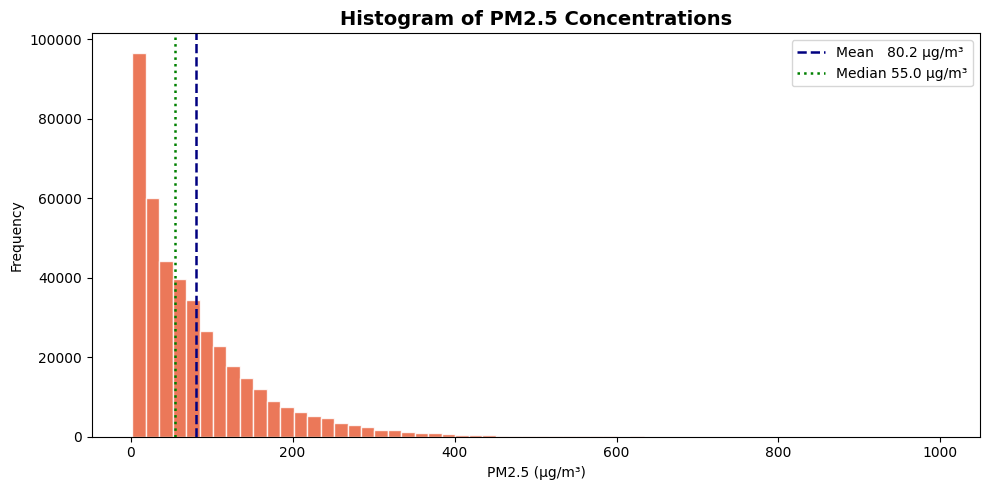

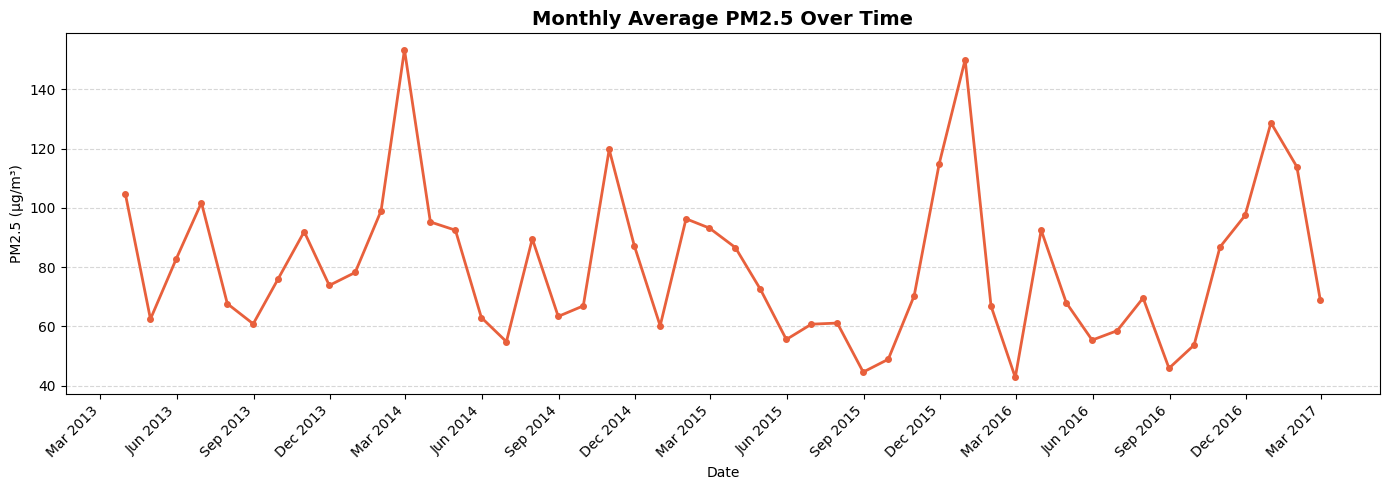

C:\Users\Asus\AppData\Local\Temp\ipykernel_17868\1114207655.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=pollutants,


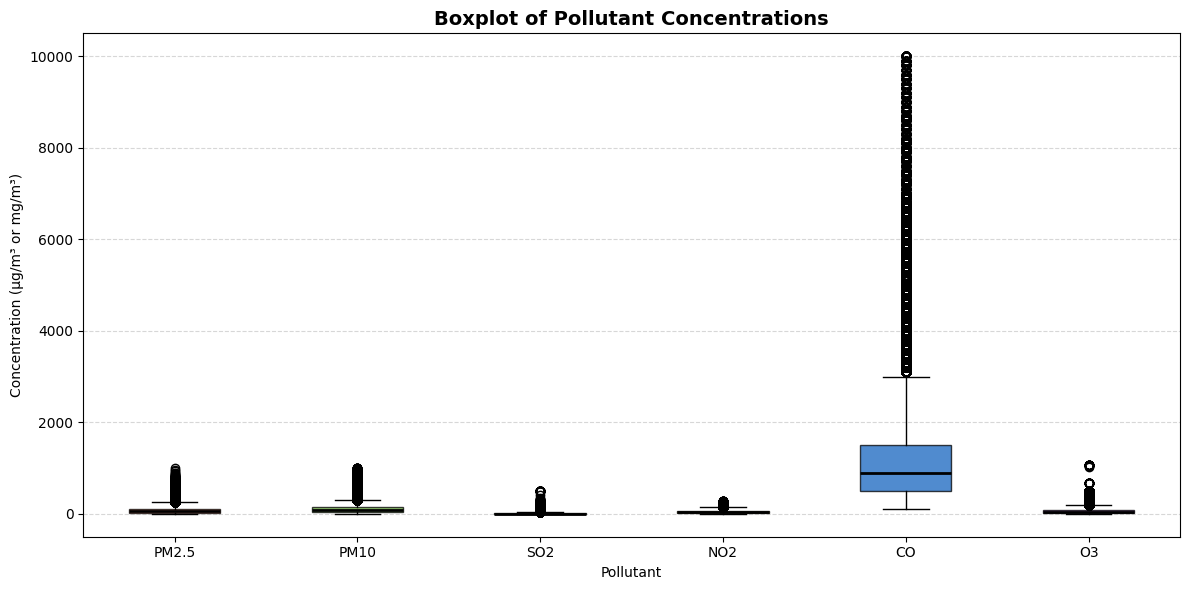

In [18]:

# TASK 5: Data Visualisation

print("TASK 5: Data Visualisation")

#  5a  Histogram of PM2.5 
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["PM2.5"].dropna(), bins=60, color="#E8603C", edgecolor="white", alpha=0.85)
ax.axvline(df["PM2.5"].mean(),   color="navy",  linestyle="--", linewidth=1.8,
           label=f"Mean   {df['PM2.5'].mean():.1f} µg/m³")
ax.axvline(df["PM2.5"].median(), color="green", linestyle=":",  linewidth=1.8,
           label=f"Median {df['PM2.5'].median():.1f} µg/m³")
ax.set_title("Histogram of PM2.5 Concentrations", fontsize=14, fontweight="bold")
ax.set_xlabel("PM2.5 (µg/m³)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/hist.png", dpi=150)
plt.show()

#  5b  Line plot of PM2.5 over time 
fig, ax = plt.subplots(figsize=(14, 5))
ts = df[["datetime", "PM2.5"]].set_index("datetime").sort_index()
ts_monthly = ts.resample("ME").mean()
ax.plot(ts_monthly.index, ts_monthly["PM2.5"],
        color="#E8603C", linewidth=2, marker="o", markersize=4)
ax.set_title("Monthly Average PM2.5 Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/line.png", dpi=150)
plt.show()


#  5c  Boxplot of pollutants 
fig, ax = plt.subplots(figsize=(12, 6))
data_to_plot = [df[c].dropna().values for c in pollutants]
bp = ax.boxplot(data_to_plot, patch_artist=True, labels=pollutants,
                medianprops=dict(color="black", linewidth=2))
colors = ["#E8603C", "#6AAF3D", "#2E7D32", "#FFC107", "#1565C0", "#7B1FA2"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_title("Boxplot of Pollutant Concentrations", fontsize=14, fontweight="bold")
ax.set_ylabel("Concentration (µg/m³ or mg/m³)")
ax.set_xlabel("Pollutant")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/box.png", dpi=150)
plt.show()



In [15]:

# TASK 6: Correlation Analysis

print("TASK 6: Correlation Analysis")


numeric_df = df.select_dtypes(include="number")

# Step 1: Correlation of all variables with PM2.5
corr_with_pm25 = numeric_df.corr()["PM2.5"].drop("PM2.5").sort_values(ascending=False)
print("\n Correlation with PM2.5 ")
print(corr_with_pm25.round(4).to_string())

# Step 2: Most correlated variable
top_var  = corr_with_pm25.idxmax()
top_corr = corr_with_pm25.max()
print(f"\n Most correlated variable with PM2.5: '{top_var}' (r = {top_corr:.4f})")

# Step 3: Temperature effect
if "TEMP" in corr_with_pm25.index:
    temp_r = corr_with_pm25["TEMP"]
    direction = "positive" if temp_r > 0 else "negative"
    strength  = "strong" if abs(temp_r) > 0.5 else ("moderate" if abs(temp_r) > 0.3 else "weak")
    print(f"\n Temperature vs PM2.5:  r = {temp_r:.4f}")
    print(f"{strength.capitalize()} {direction} relationship.")
    if temp_r < 0:
        print("Higher temperatures are associated with LOWER PM2.5 levels.")
    else:
        print("Higher temperatures are associated with HIGHER PM2.5 levels.")




TASK 6: Correlation Analysis

 Correlation with PM2.5 
PM10     0.8762
CO       0.7730
NO2      0.6543
SO2      0.4692
DEWP     0.1128
PRES     0.0191
hour     0.0106
month    0.0071
day      0.0044
RAIN    -0.0142
No      -0.0250
year    -0.0265
TEMP    -0.1305
O3      -0.1447
WSPM    -0.2696

 Most correlated variable with PM2.5: 'PM10' (r = 0.8762)

 Temperature vs PM2.5:  r = -0.1305
Weak negative relationship.
Higher temperatures are associated with LOWER PM2.5 levels.
